# Feature Selection on the Breast Cancer Dataset

A compact comparison of feature selection and dimensionality reduction methods before training KNN classifiers.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, RFE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

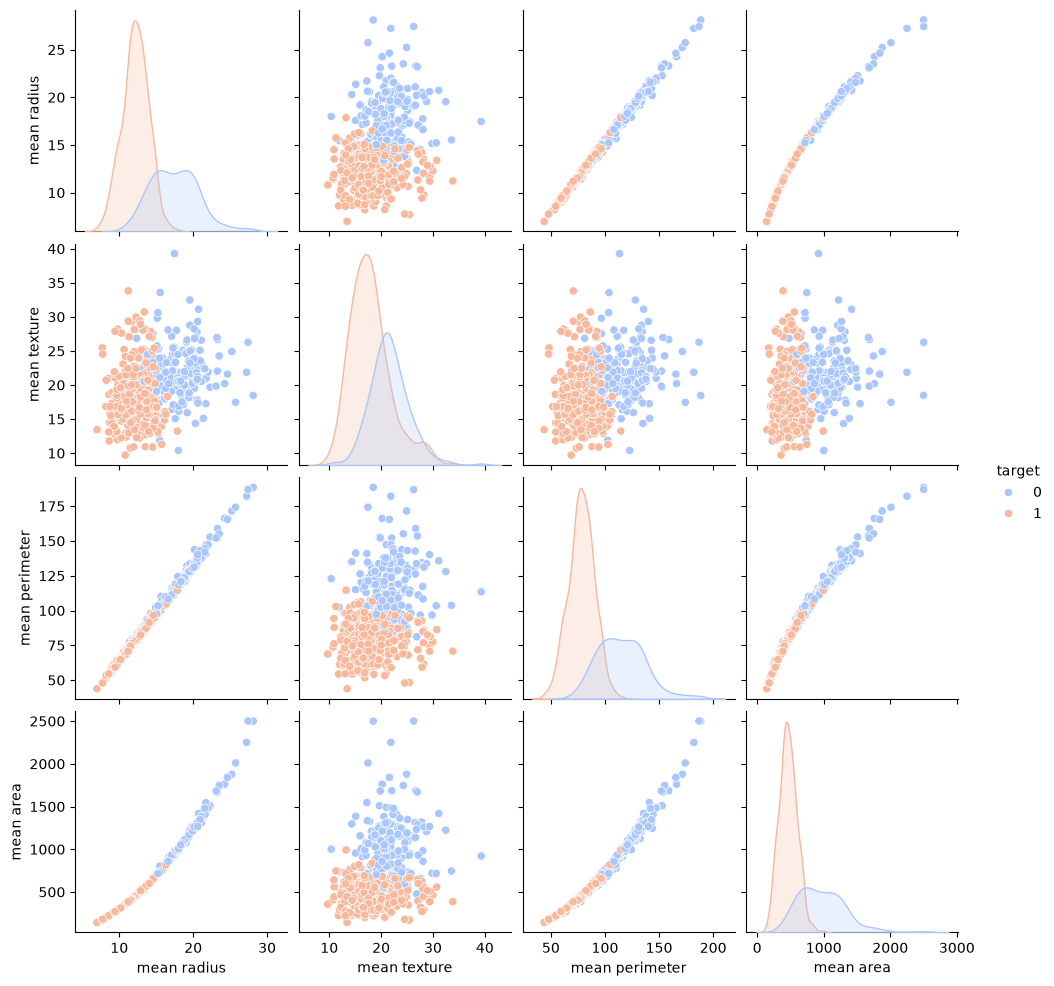

In [3]:
# Add the target column only for exploratory plots.
df = X.copy()
df['target'] = y

# Plot for pairplot for a subset of features
sns.pairplot(df, vars=X.columns[:4], hue='target', palette='coolwarm')
plt.show()




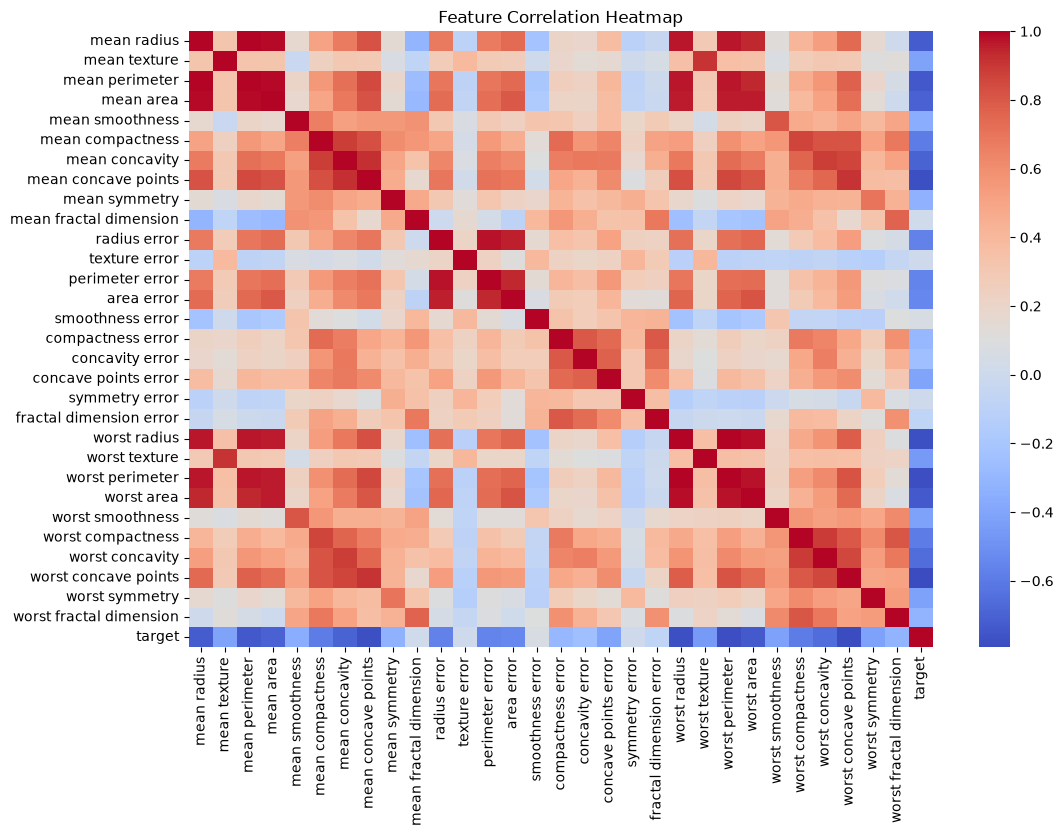

In [4]:
# Plot for correlation heatmap
corr_mat = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_mat, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()



C:\Users\daniy\AppData\Local\Temp\ipykernel_29648\641221753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='mean radius', data=df, palette="coolwarm")


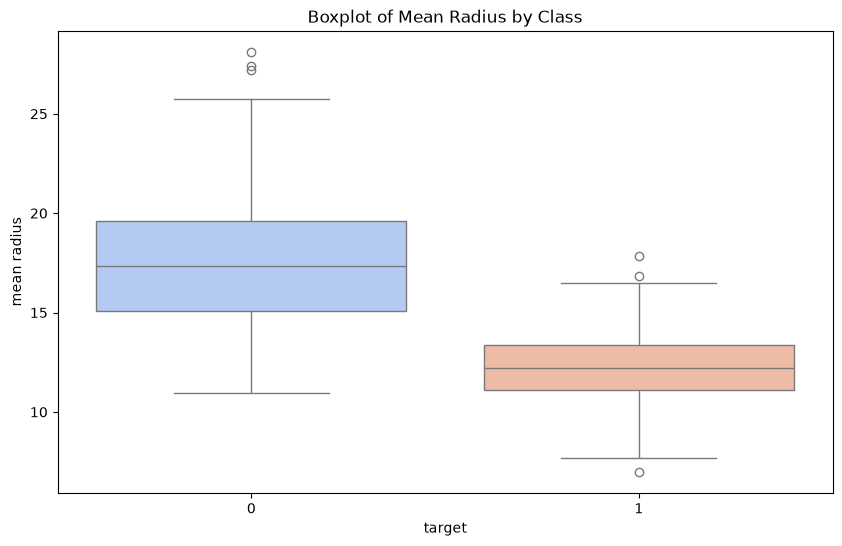

In [5]:

# Plot to show the Boxplot of "mean radius" features
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='mean radius', data=df, palette="coolwarm")
plt.title("Boxplot of Mean Radius by Class")
plt.show()

KNN Accuracy: 0.9473684210526315


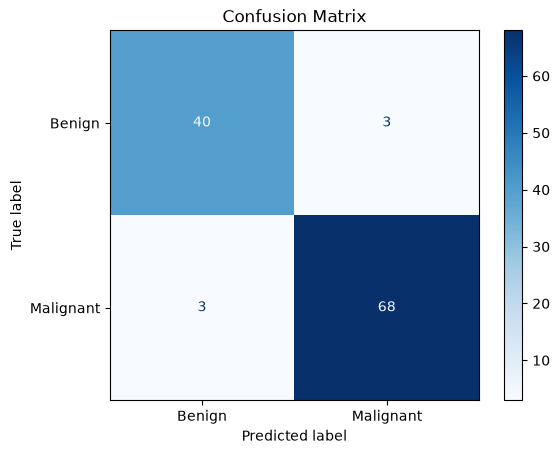

In [6]:
from sklearn.model_selection import train_test_split
# Split into train and test sets (80-20)
X = df.drop('target', axis = 1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, train_size=0.8, random_state=42, shuffle=True)

# Standardize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit on the training split and evaluate once on the holdout split.
def evaluate_knn(X_train, X_test, y_train, y_test):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return acc, cm

accuracy, conf_matrix = evaluate_knn(X_train_scaled, X_test_scaled, y_train, y_test)

print("KNN Accuracy:", accuracy)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["Benign", "Malignant"])  # Adjust labels based on dataset
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


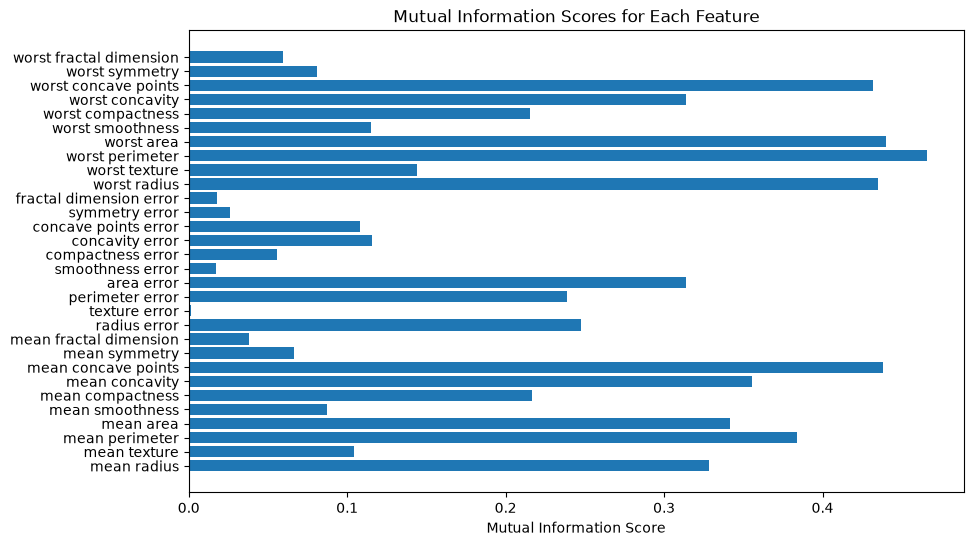

In [7]:
# ========================= Feature Selection Methods =========================

# 1. Mutual Information
mi_scores = mutual_info_classif(X_train_scaled, y_train)
mi_selected_features = np.argsort(mi_scores)[-10:]  # Select top 10 features
X_train_mi = X_train_scaled[:, mi_selected_features]
X_test_mi = X_test_scaled[:, mi_selected_features]

import matplotlib.pyplot as plt

# Plot Mutual Information Scores
plt.figure(figsize=(10, 6))
plt.barh(X.columns, mi_scores)
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information Scores for Each Feature')
plt.show()


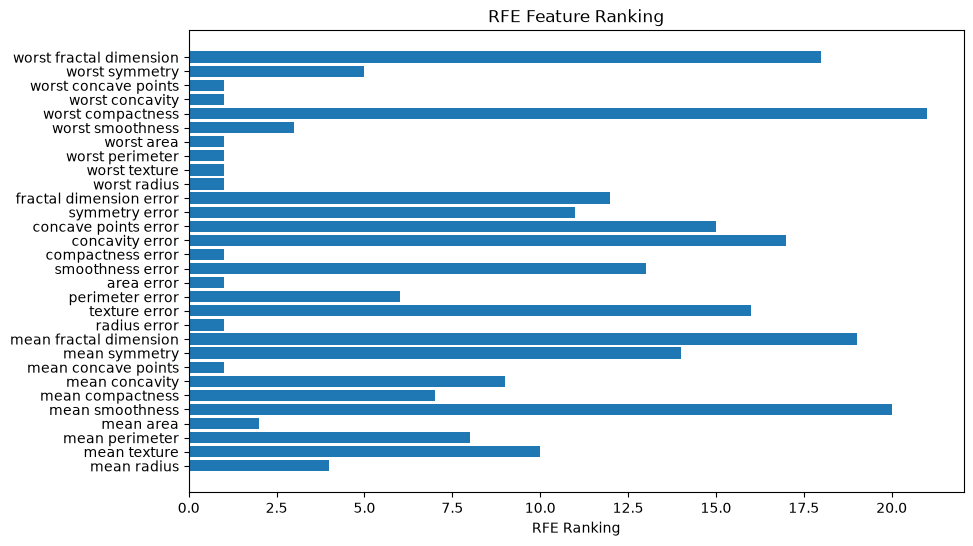

In [8]:
# ========================= Feature Selection Methods =========================

# 2. Recursive Feature Elimination (RFE)
from sklearn.linear_model import LogisticRegression
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Get feature ranking from RFE
rfe_ranking = rfe.ranking_

# Plot RFE Rankings
plt.figure(figsize=(10, 6))
plt.barh(X.columns, rfe_ranking)
plt.xlabel('RFE Ranking')
plt.title('RFE Feature Ranking')
plt.show()

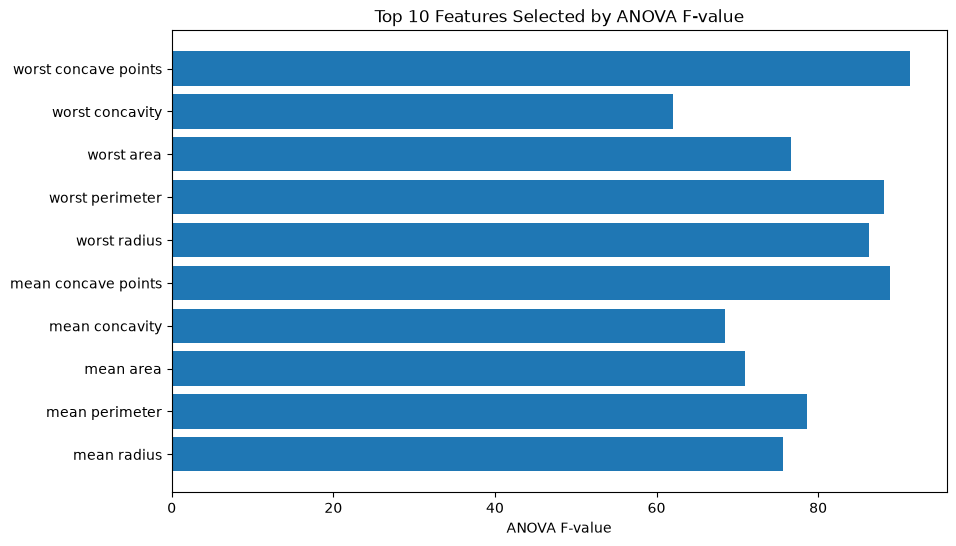

In [9]:
import numpy as np

# Apply a shift to make all values non-negative
X_train_scaled = X_train_scaled - np.min(X_train_scaled)  # Shift to make all values >= 0
X_test_scaled = X_test_scaled - np.min(X_test_scaled)  # Shift to make all values >= 0

# Now, apply SelectKBest with chi2
chi_selector = SelectKBest(chi2, k=10)
X_train_f = chi_selector.fit_transform(X_train_scaled, y_train)
X_test_f = chi_selector.transform(X_test_scaled)

# Get selected feature indices
selected_features_f = X.columns[chi_selector.get_support()]

# Visualizing selected features
plt.figure(figsize=(10, 6))
plt.barh(selected_features_f, chi_selector.scores_[chi_selector.get_support()])
plt.xlabel('ANOVA F-value')
plt.title('Top 10 Features Selected by ANOVA F-value')
plt.show()

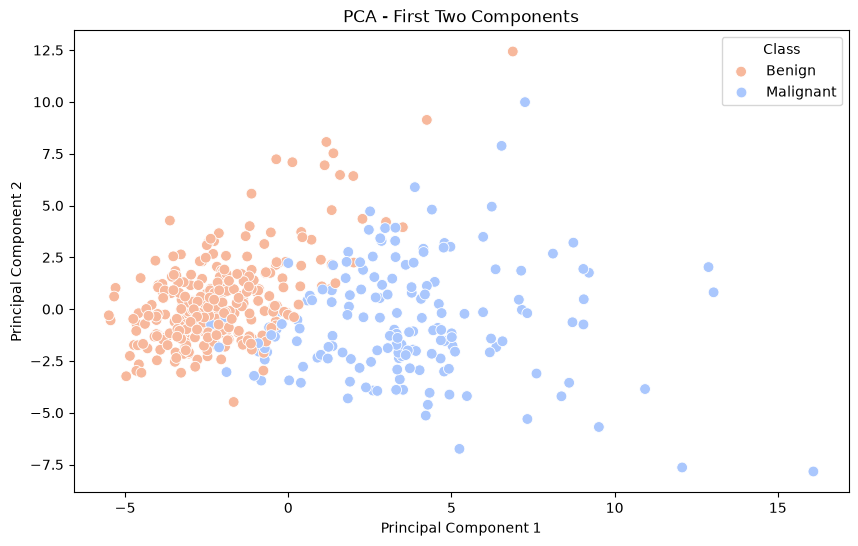

In [10]:
# ========================= Dimensionality Reduction Methods =========================

# 4. PCA (reduce to 10 principal components)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# PCA Visualization: Plot first two components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette="coolwarm", s=60)
plt.title("PCA - First Two Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Class", labels=["Benign", "Malignant"])
plt.show()




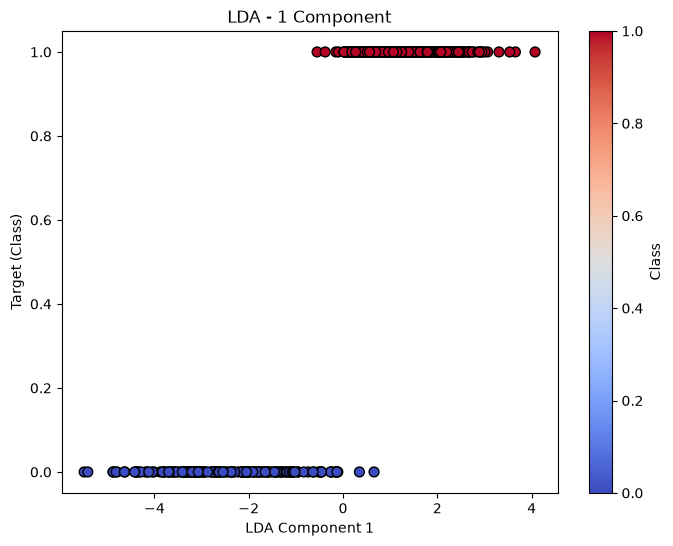

In [11]:
# ========================= Dimensionality Reduction Methods =========================

# 5. LDA (reduce to 1 component, since LDA max components = min(classes-1, features))
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)


# LDA Visualization: Plot the LDA result
plt.figure(figsize=(8, 6))
plt.scatter(X_train_lda, y_train, c=y_train, cmap='coolwarm', edgecolor='k', s=50)
plt.title('LDA - 1 Component')
plt.xlabel('LDA Component 1')
plt.ylabel('Target (Class)')
plt.colorbar(label='Class')
plt.show()




In [12]:
# ========================= KNN Performance Evaluation =========================

# Evaluate performance on different feature selection methods
acc_mi, cm_mi = evaluate_knn(X_train_mi, X_test_mi, y_train, y_test)
acc_rfe, cm_rfe = evaluate_knn(X_train_rfe, X_test_rfe, y_train, y_test)
acc_f, cm_f = evaluate_knn(X_train_f, X_test_f, y_train, y_test)

# Evaluate performance on PCA
acc_pca, cm_pca = evaluate_knn(X_train_pca, X_test_pca, y_train, y_test)

# Evaluate performance on LDA
acc_lda, cm_lda = evaluate_knn(X_train_lda, X_test_lda, y_train, y_test)



In [13]:
# ========================= Results Display =========================

# Print Accuracy Scores
print("\nKNN Classifier Performance (Accuracy Scores):")
print(f"Mutual Information: {acc_mi:.4f}")
print(f"Recursive Feature Elimination: {acc_rfe:.4f}")
print(f"F Test: {acc_f:.4f}")
print(f"PCA: {acc_pca:.4f}")
print(f"LDA: {acc_lda:.4f}")



KNN Classifier Performance (Accuracy Scores):
Mutual Information: 0.9737
Recursive Feature Elimination: 0.9737
F Test: 0.8860
PCA: 0.9035
LDA: 0.9386


In [14]:

# Display Confusion Matrices
conf_matrices = {'Mutual Information': cm_mi, 'RFE': cm_rfe, 'Chi-square': cm_f, 'PCA': cm_pca, 'LDA': cm_lda}


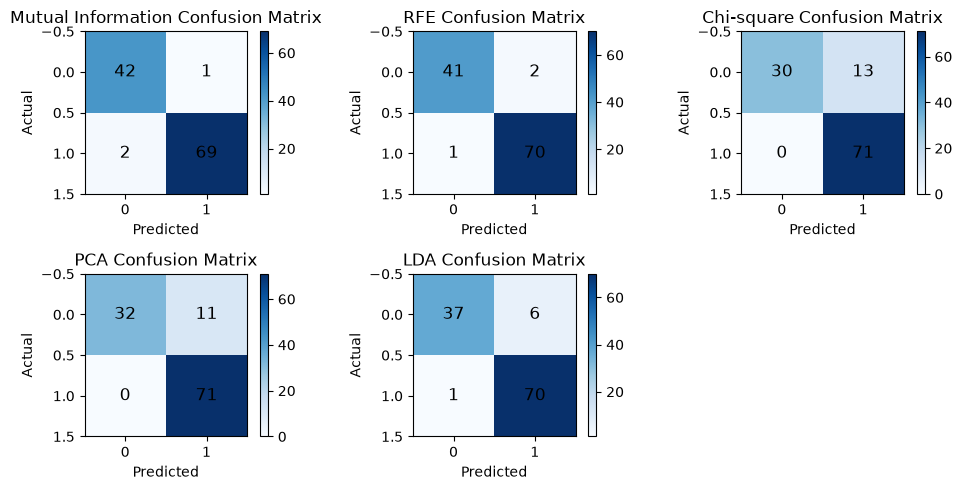

In [15]:

plt.figure(figsize=(10, 5))
for i, (key, cm) in enumerate(conf_matrices.items(), 1):
    plt.subplot(2, 3, i)
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"{key} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    # Add numbers inside the confusion matrix
    for (j, k), val in np.ndenumerate(cm):
        plt.text(k, j, str(val), ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()